# MICrONS Structural Dataset Exploration

This notebook explores the structural data used in the basic tutorial, focusing on nucleus-level metadata and synaptic connectivity.

## 1) Imports and setup

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import microns_datacleaner as mic
import microns_datacleaner.filters as fl

plt.style.use('seaborn-v0_8-whitegrid')

## 2) Load structural tables

We rebuild the nucleus/unit table from the same dataset version (`1718`) and try to load the merged synapse table generated in the tutorial (`example_merged_synapses.csv`).

In [2]:
cleaner = mic.MicronsDataCleaner(datadir='data', version=1718, download_policy='minimum')
units, segments = cleaner.process_nucleus_data(functional_data='best_only')

syn_path = Path('data/1718/raw/example_merged_synapses.csv')
if syn_path.exists():
    synapses = pd.read_csv(syn_path)
else:
    synapses = None

print(f'units shape: {units.shape}')
print(f'segments shape: {segments.shape}')
print(f'synapses loaded: {synapses is not None}')
if synapses is not None:
    print(f'synapses shape: {synapses.shape}')

Transform positions: 100%|██████████| 94014/94014 [00:01<00:00, 90771.69it/s]


units shape: (90434, 20)
segments shape: (5, 5)
synapses loaded: True
synapses shape: (13019, 3)


## 3) Quick schema and missingness checks

Use this section to inspect sample rows, data types, and missing-value patterns before deeper analysis.

In [3]:
display(units.head(3))

feature_summary = pd.DataFrame({
    'dtype': units.dtypes.astype(str),
    'n_distinct_non_null': units.nunique(dropna=True),
    'n_distinct_including_nan': units.nunique(dropna=False),
    'fraction_missing': units.isna().mean()
}).sort_index()

display(feature_summary)

# Optional compact view sorted by distinct cardinality
display(feature_summary.sort_values('n_distinct_non_null', ascending=False))


,nucleus_id,pt_root_id,pt_position_x,pt_position_y,pt_position_z,classification_system,cell_type,brain_area,strategy_axon,strategy_dendrite,session,scan_idx,unit_id,pref_ori,pref_dir,gOSI,gDSI,cc_abs,tuning_type,layer
0,373879,864691136090135607,828.189723,638.553801,783.72,excitatory_neuron,6P-CT,V1,none,none,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,not_matched,L6
1,408486,864691135194387242,891.157407,662.693656,1002.96,nonneuron,oligo,V1,none,none,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,not_matched,L6
2,199883,864691136041571414,514.440335,481.908658,1044.32,excitatory_neuron,5P-ET,V1,none,none,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,not_matched,L5


,dtype,n_distinct_non_null,n_distinct_including_nan,fraction_missing
brain_area,object,4,4,0.000000
cc_abs,float64,12869,12870,0.856193
cell_type,object,16,16,0.000000
classification_system,object,3,3,0.000000
gDSI,float64,12865,12866,0.856193
gOSI,float64,12844,12845,0.856193
layer,object,5,6,0.000011
nucleus_id,int64,90434,90434,0.000000
pref_dir,float64,12849,12850,0.856193
pref_ori,float64,12849,12850,0.856193


,dtype,n_distinct_non_null,n_distinct_including_nan,fraction_missing
pt_root_id,int64,90434,90434,0.000000
nucleus_id,int64,90434,90434,0.000000
pt_position_y,float64,90412,90412,0.000000
pt_position_x,float64,90412,90412,0.000000
cc_abs,float64,12869,12870,0.856193
gDSI,float64,12865,12866,0.856193
pref_dir,float64,12849,12850,0.856193
pref_ori,float64,12849,12850,0.856193
gOSI,float64,12844,12845,0.856193
pt_position_z,float64,12538,12538,0.000000




This section documents each feature in the current table schema and groups them by role in analysis.

### A) Spatial and anatomical context

1. brain_area (object)
   - Cortical area label for the unit (for example V1, AL, RL, LM).
   - Useful for area-specific filtering and area-to-area connectivity summaries.

2. layer (object)
   - Cortical layer assignment (for example L2/3, L4, L5, L6).
   - Commonly used to study laminar connectivity patterns.

3. pt_position_x (float64)
   - X coordinate of the unit position in the aligned coordinate system.

4. pt_position_y (float64)
   - Y coordinate of the unit position in the aligned coordinate system.

5. pt_position_z (float64)
   - Z coordinate (depth axis in many workflows).
   - Together with X and Y, defines the 3D spatial location.

### B) Identity and cross-table keys

6. nucleus_id (int64)
   - Nucleus-level identifier used as a stable merge key across many structural tables.

7. pt_root_id (int64)
   - Segmentation root identifier used heavily in synapse tables (pre and post endpoints).
   - Important for graph construction from synapse edge lists.

8. unit_id (float64)
   - Functional unit index from coregistration context.
   - Often represented as float because missing values can appear when a structural unit is not matched.

9. session (float64)
   - Functional recording session identifier associated with a matched unit.

10. scan_idx (float64)
   - Scan index within a session for matched units.

### C) Cell annotation and classification

11. cell_type (object)
   - Fine-grained cell type category (for example AIBS-derived classes).
   - Used for subtype-based analysis and composition summaries.

12. classification_system (object)
   - Higher-level classification source/system (for example neuron vs non-neuron families or taxonomy namespace).
   - Helps interpret how cell_type labels were assigned.

### D) Functional tuning and response-quality descriptors

13. pref_ori (float64)
   - Preferred orientation angle estimated from tuning analysis.

14. pref_dir (float64)
   - Preferred direction angle estimated from direction tuning analysis.

15. gOSI (float64)
   - Global Orientation Selectivity Index.
   - Higher values indicate stronger orientation selectivity.

16. gDSI (float64)
   - Global Direction Selectivity Index.
   - Higher values indicate stronger direction selectivity.

17. cc_abs (float64)
   - Absolute correlation-style quality metric from model fit/evaluation context.
   - Often used to select best scan/match quality among candidates.

18. tuning_type (object)
   - Tuning/coregistration status label (for example matched, not_matched, or mode-specific categories).
   - Useful for filtering to reliable functionally linked units.

### E) Reconstruction and proofreading strategy metadata

19. strategy_axon (object)
   - Proofreading/reconstruction strategy annotation for the axonal compartment.
   - Useful for quality-control filters (for example restricting to cleaner axons).

20. strategy_dendrite (object)
   - Proofreading/reconstruction strategy annotation for the dendritic compartment.
   - Useful for quality-control filters and confidence stratification.

### Practical notes

1. Float columns with identifiers (such as unit_id, session, scan_idx) usually indicate that missing values are allowed in the table.
2. Not every analysis needs all groups:
   - Structural-only analyses usually rely on nucleus_id, pt_root_id, area/layer, and proofreading strategy fields.
   - Structure-function analyses additionally require unit_id, session, scan_idx, and tuning metrics.
3. Column availability can vary with processing mode and package version, so always verify schema before downstream modeling.


### Keep only functionally matched neurons

This project uses **functional data as input**, so we must restrict the structural label table to neurons that have a valid functional association in the MICrONS pipeline.

In practice, this means keeping only rows with `tuning_type == 'matched'`, and discarding neurons labeled as `not_matched`.

In [4]:
if 'tuning_type' not in units.columns:
    print("Column 'tuning_type' is not available; cannot filter matched neurons.")
else:
    n_before = len(units)
    units = units[units['tuning_type'].astype(str) == 'matched'].copy()
    n_after = len(units)
    print(f'Applied matched-neuron filter: {n_before} -> {n_after} rows retained ({n_after / n_before:.2%}).')

Applied matched-neuron filter: 90434 -> 13005 rows retained (14.38%).


In [5]:

# Print the 3 different classification values and associated datapoint counts
class_col = 'classification_type' if 'classification_type' in units.columns else 'classification_system'
class_counts = units[class_col].value_counts(dropna=False).head(3)
print(f'Top 3 values for {class_col}:')
display(class_counts.rename('n_datapoints').to_frame())

Top 3 values for classification_system:


,n_datapoints
classification_system,
excitatory_neuron,12938
inhibitory_neuron,63
nonneuron,4


## 5) Data cleaning decisions for this study

Based on the diagnostics above, the datapoint with missing `layer` does not contain useful annotation for the analyses in this notebook, so we remove it.

We also remove non-neuronal objects (`nonneuron`). In addition, inhibitory neurons are too underrepresented for a stable and meaningful classification setup in this project.

Therefore, for this study we focus on **excitatory neurons only**.

The next cell applies these filters and reports how many rows are removed at each step.

In [6]:
# Keep a copy of the original table
units_raw = units.copy()

n_start = len(units_raw)

# 1) Drop datapoints with missing layer
units_clean = units_raw[units_raw['layer'].notna()].copy()
n_after_layer = len(units_clean)
n_removed_layer = n_start - n_after_layer

# 2) Keep only excitatory neurons for this project
class_col = 'classification_system' if 'classification_system' in units_clean.columns else 'classification_type'
class_series = units_clean[class_col].astype(str).str.lower()

n_removed_nonneuron = int(class_series.eq('nonneuron').sum())
n_removed_inhibitory = int(class_series.eq('inhibitory_neuron').sum())

units_clean = units_clean[class_series.eq('excitatory_neuron')].copy()

n_final = len(units_clean)

print(f'Rows at start: {n_start}')
print(f'Removed for missing layer: {n_removed_layer}')
print(f'Removed as nonneuron: {n_removed_nonneuron}')
print(f'Removed as inhibitory_neuron: {n_removed_inhibitory}')
print(f'Rows after keeping excitatory_neuron only: {n_final}')

# Use cleaned table for subsequent analyses
units = units_clean

Rows at start: 13005
Removed for missing layer: 0
Removed as nonneuron: 4
Removed as inhibitory_neuron: 63
Rows after keeping excitatory_neuron only: 12938


## Distribution of `cc_abs`

`cc_abs` is a **functional quality score**: it tells how well the Digital Twin model predicts a neuron's response. In simple terms, higher means the functional response is more reliably captured by the model.

Practical interpretation:
1. Values closer to **1**: stronger/better model agreement (higher confidence in that unit's functional summary).
2. Values closer to **0**: weaker agreement (noisier or less predictable response for that unit).
3. There is no universal "good" cutoff; interpret `cc_abs` relative to your dataset (for example by quantiles).

How to use it in practice:
1. Use it as a **quality filter** (for example keep top quantiles, or run sensitivity checks with multiple thresholds).
2. Use it as a **confidence weight** in downstream analyses.
3. Avoid using it as a biological label itself; treat it as a reliability indicator.

Valid cc_abs datapoints: 12938 / 12938


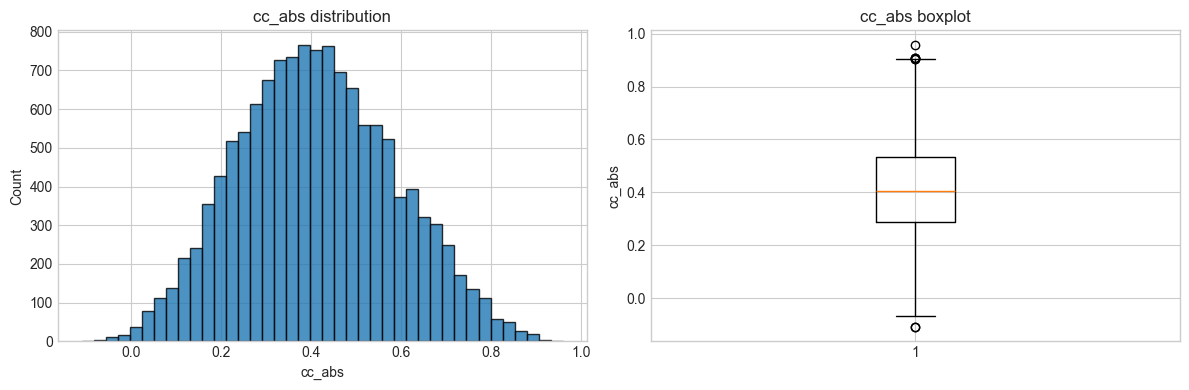

In [7]:
if 'cc_abs' not in units.columns:
    print("Column 'cc_abs' is not available in the current units table.")
else:
    cc = pd.to_numeric(units['cc_abs'], errors='coerce').dropna()
    print(f'Valid cc_abs datapoints: {len(cc)} / {len(units)}')

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(cc, bins=40, edgecolor='black', alpha=0.8)
    axes[0].set_title('cc_abs distribution')
    axes[0].set_xlabel('cc_abs')
    axes[0].set_ylabel('Count')

    axes[1].boxplot(cc, vert=True)
    axes[1].set_title('cc_abs boxplot')
    axes[1].set_ylabel('cc_abs')

    plt.tight_layout()
    plt.show()

## Reconstruction and proofreading feature distributions

This section prints and plots the distributions of `strategy_axon`, `strategy_dendrite`, `status_axon`, and `status_dendrite`.

In [8]:
proof_cols = ['strategy_axon', 'strategy_dendrite', 'status_axon', 'status_dendrite']

# Start from units; if some columns are missing, try the raw proofreading table.
proof_df = units.copy()
missing_cols = [c for c in proof_cols if c not in proof_df.columns]

if len(missing_cols) > 0:
    raw_path = Path('data/1718/raw/proofreading_status_and_strategy.csv')
    if raw_path.exists():
        proof_raw = pd.read_csv(raw_path)
        for c in missing_cols:
            if c in proof_raw.columns:
                proof_df[c] = proof_raw[c]
    else:
        print(f'Raw proofreading table not found: {raw_path}')

available_cols = [c for c in proof_cols if c in proof_df.columns]
if len(available_cols) == 0:
    print('No proofreading/reconstruction features are available to plot.')
else:
    # Print count tables
    for col in available_cols:
        print(f'\nDistribution for {col}:')
        display(proof_df[col].astype(str).value_counts(dropna=False).rename('count').to_frame())

    


Distribution for strategy_axon:


,count
strategy_axon,
none,12032
axon_partially_extended,616
axon_fully_extended,174
axon_interareal,116



Distribution for strategy_dendrite:


,count
strategy_dendrite,
none,12023
dendrite_extended,691
dendrite_clean,224



Distribution for status_axon:


,count
status_axon,
nan,12627
True,309
False,2



Distribution for status_dendrite:


,count
status_dendrite,
nan,12627
True,305
False,6


## Class-label distributions (`cell_type`, `layer`, `brain_area`)

These tables show the class balance of the labels used for classification tasks, reporting both counts and percentages over the total number of rows.

In [9]:
label_cols = ['cell_type', 'layer', 'brain_area']
available = [c for c in label_cols if c in units.columns]

if len(available) == 0:
    print('None of the requested label columns are available in units.')
else:
    n_total = len(units)
    print(f'Total rows considered: {n_total}')

    for col in available:
        counts = units[col].astype(str).value_counts(dropna=False).rename('count')
        summary = counts.to_frame()
        summary['percentage'] = 100 * summary['count'] / n_total
        summary['percentage'] = summary['percentage'].map(lambda x: f'{x:.2f}%')

        print(f'\nDistribution for {col}:')
        display(summary)

Total rows considered: 12938

Distribution for cell_type:


,count,percentage
cell_type,,
23P,6059,46.83%
4P,4143,32.02%
5P-IT,1756,13.57%
5P-ET,507,3.92%
6P-IT,284,2.20%
6P-CT,151,1.17%
5P-NP,38,0.29%



Distribution for layer:


,count,percentage
layer,,
L2/3,6060,46.84%
L4,4046,31.27%
L5,2325,17.97%
L6,485,3.75%
L1,22,0.17%



Distribution for brain_area:


,count,percentage
brain_area,,
V1,8910,68.87%
RL,3199,24.73%
AL,809,6.25%
LM,20,0.15%


## Project focus: V1-only subset

For this project, we focus on neurons in the **V1** brain area.
Therefore, before joint-label analysis, we filter the dataset to keep only cells with `brain_area == 'V1'`.

In [10]:
if 'brain_area' not in units.columns:
    print("Column 'brain_area' is not available; cannot filter to V1.")
else:
    n_before = len(units)
    units = units[units['brain_area'].astype(str) == 'V1'].copy()
    n_after = len(units)
    print(f'Applied V1 filter: {n_before} -> {n_after} rows retained ({n_after / n_before:.2%}).')

Applied V1 filter: 12938 -> 8910 rows retained (68.87%).


## Joint label distribution (high-dimensional view)

A practical way to visualize joint distributions across many labels is to combine:
1. **Top full combinations**: most frequent tuples across all labels.
2. **Pairwise heatmaps**: two-label contingency maps, after compressing rare categories into `OTHER` to keep plots readable.

This gives both a global and a pairwise view without exploding dimensionality.

Using label columns: ['cell_type', 'layer']

Cardinality per label:


,n_categories
cell_type,7
layer,5


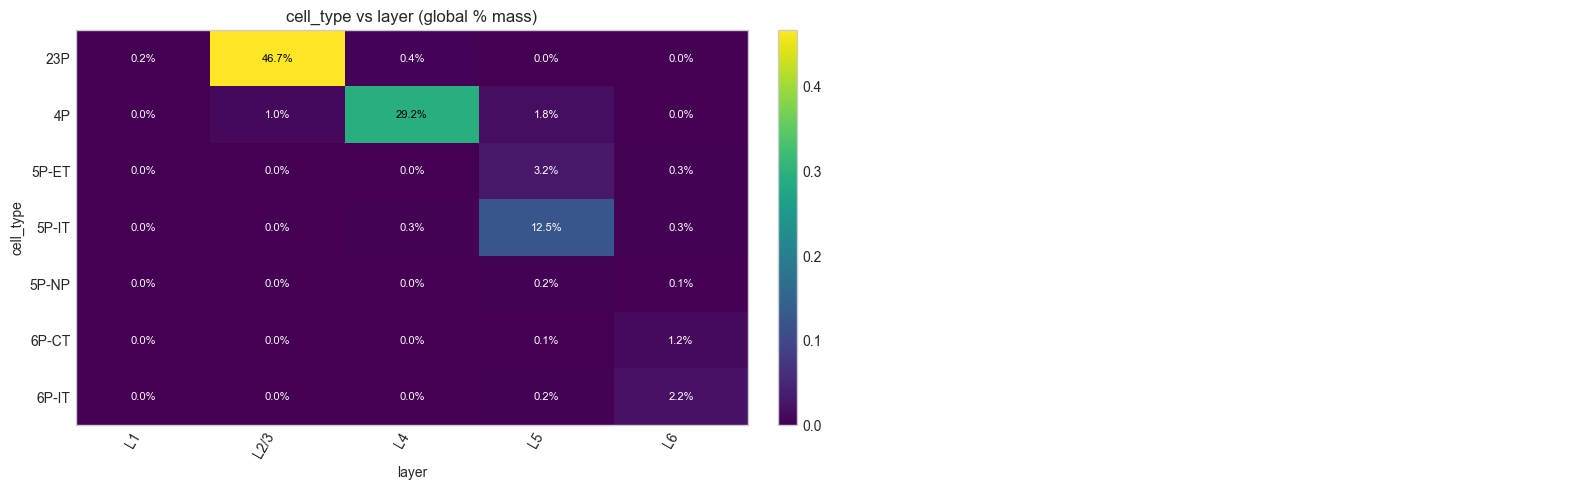

In [11]:
from itertools import combinations

# Joint labels after filtering (V1 + matched + excitatory)
label_cols = ['cell_type', 'layer']
available = [c for c in label_cols if c in units.columns]

if len(available) < 2:
    print('Need at least two available label columns to study joint distributions.')
else:
    labels_df = units[available].copy()
    labels_df = labels_df.fillna('MISSING').astype(str)

    # Drop constant columns (if any)
    nunique = labels_df.nunique()
    used_cols = nunique[nunique > 1].index.tolist()
    dropped_constant = nunique[nunique <= 1].index.tolist()

    if len(dropped_constant) > 0:
        print('Dropped constant label columns:', dropped_constant)

    if len(used_cols) < 2:
        print('Need at least two non-constant label columns to plot joint distributions.')
    else:
        labels_df = labels_df[used_cols]
        print('Using label columns:', used_cols)

        # Report cardinality
        cardinality = labels_df.nunique().sort_values(ascending=False).rename('n_categories')
        print('\nCardinality per label:')
        display(cardinality.to_frame())

        # Pairwise heatmaps with rare-category compression + cell percentages
        def compress_categories(s, top_n=12):
            top_vals = s.value_counts().head(top_n).index
            return np.where(s.isin(top_vals), s, 'OTHER')

        compressed = labels_df.copy()
        for c in used_cols:
            compressed[c] = compress_categories(compressed[c], top_n=12)

        pairs = list(combinations(used_cols, 2))
        n_pairs = len(pairs)
        ncols = 2
        nrows = int(np.ceil(n_pairs / ncols))
        fig, axes = plt.subplots(nrows, ncols, figsize=(8 * ncols, 5 * nrows))
        axes = np.array(axes).reshape(-1)

        for i, (a, b) in enumerate(pairs):
            ct = pd.crosstab(compressed[a], compressed[b])
            # Normalize globally to show probability mass in each cell
            mat = ct / ct.values.sum()

            im = axes[i].imshow(mat.values, aspect='auto', cmap='viridis')
            axes[i].set_title(f'{a} vs {b} (global % mass)')
            axes[i].set_xlabel(b)
            axes[i].set_ylabel(a)
            axes[i].set_xticks(range(len(mat.columns)))
            axes[i].set_xticklabels(mat.columns, rotation=60, ha='right')
            axes[i].set_yticks(range(len(mat.index)))
            axes[i].set_yticklabels(mat.index)
            axes[i].grid(False)

            # Annotate each cell with percentage
            for r in range(mat.shape[0]):
                for c in range(mat.shape[1]):
                    pct = 100 * mat.values[r, c]
                    text_color = 'black' if mat.values[r, c] > 0.5 * mat.values.max() else 'white'
                    axes[i].text(c, r, f'{pct:.1f}%', ha='center', va='center', color=text_color, fontsize=8)

            fig.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)

        for j in range(i + 1, len(axes)):
            axes[j].axis('off')

        plt.tight_layout()
        plt.show()